In [1]:
import os
import scanpy as sc
import pandas as pd
from sklearn.metrics import normalized_mutual_info_score

In [5]:
# 1. Highly variable genes selection
sc.pp.highly_variable_genes(
    adata,
    flavor='seurat',   # 
    n_top_genes=2000,  # typical number of HVGs
    subset=True        # keeps only HVGs in adata.X
)


# 2. Scale the HVGs
sc.pp.scale(adata, max_value=10)  # optional, caps extreme values

# 3. PCA on HVGs
sc.tl.pca(adata, svd_solver='arpack')


# Compute neighbors graph (heavy step)
sc.pp.neighbors(
    adata,
    n_neighbors=15,
    n_pcs=50,
    random_state=0
)

# Optional: compute UMAP now for visualization
sc.tl.umap(adata, random_state=0)

# Save state for reuse
adata.write('adata_graph_ready.h5ad')


adata = sc.read('adata_graph_ready.h5ad')

# Define the resolutions you want to try
resolutions = [0.3, 0.5, 0.8, 1.0]

for res in resolutions:
    key = f'leiden_r{res}'  # unique key for each resolution
    sc.tl.leiden(
        adata,
        resolution=res,
        key_added=key,
        random_state=0
    )
    # Optional: visualize UMAP colored by this resolution
    #sc.pl.umap(adata, color=key, save=f'_{key}.png')
adata.write('adata_graph_leiden_multiple_resolutions.h5ad')


In [13]:
# Load precomputed graph + multiple resolutions
adata = sc.read('adata_graph_leiden_multiple_resolutions.h5ad')

# Make a copy of relevant metadata
df_meta = adata.obs[['cell_type', 'disease']].copy()

# Create a combined label: "disease_celltype"
adata.obs['disease_celltype'] = adata.obs['disease'].astype(str) + '_' + adata.obs['cell_type'].astype(str)

# List of Leiden cluster columns
leiden_cols = [col for col in adata.obs.columns if col.startswith('leiden_r')]

# Compute NMI for each resolution
nmi_results = []

for col in leiden_cols:
    nmi_celltype = normalized_mutual_info_score(adata.obs[col], adata.obs['cell_type'])
    nmi_disease = normalized_mutual_info_score(adata.obs[col], adata.obs['disease'])
    nmi_mixed = normalized_mutual_info_score(adata.obs[col], adata.obs['disease_celltype'])
    
    print(f"{col}: NMI vs Cell Type = {nmi_celltype:.3f}, "
          f"NMI vs Disease = {nmi_disease:.3f}, "
          f"NMI vs Disease+CellType = {nmi_mixed:.3f}")
    
    nmi_results.append({
        'resolution': col,
        'nmi_cell_type': nmi_celltype,
        'nmi_disease': nmi_disease,
        'nmi_disease_celltype': nmi_mixed
    })

# Save results to CSV
df_nmi = pd.DataFrame(nmi_results)
df_nmi.to_csv('nmi_results_by_resolution.csv', index=False)


leiden_r0.3: NMI vs Cell Type = 0.821, NMI vs Disease = 0.001, NMI vs Disease+CellType = 0.721
leiden_r0.5: NMI vs Cell Type = 0.718, NMI vs Disease = 0.009, NMI vs Disease+CellType = 0.645
leiden_r0.8: NMI vs Cell Type = 0.697, NMI vs Disease = 0.011, NMI vs Disease+CellType = 0.630
leiden_r1.0: NMI vs Cell Type = 0.661, NMI vs Disease = 0.012, NMI vs Disease+CellType = 0.602


In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
from sklearn.metrics import normalized_mutual_info_score

adata = sc.read("/home/znazari/scRNAseq_parkinson/result/adata_graph_leiden_multiple_resolutions.h5ad")
print("Loaded:", adata.shape)


Loaded: (2096155, 2000)


In [4]:
required_cols = ["disease", "cell_type"]
missing = [c for c in required_cols if c not in adata.obs.columns]
if len(missing) > 0:
    raise ValueError(f"Missing metadata columns: {missing}")


In [5]:
# Create combined celltype_condition label
adata.obs["celltype_condition"] = (
    adata.obs["cell_type"].astype(str) + "_" +
    adata.obs["disease"].astype(str)
)


In [6]:
leiden_cols = [c for c in adata.obs.columns if c.startswith("leiden")]
print("Found clustering columns:", leiden_cols)


Found clustering columns: ['leiden_r0.3', 'leiden_r0.5', 'leiden_r0.8', 'leiden_r1.0']


In [7]:
results = []
unique_classes = adata.obs["celltype_condition"].dropna().unique()

for cluster_key in leiden_cols:
    res = float(cluster_key.replace("leiden_r", ""))
    print(f"Processing resolution {res}")

    valid = adata.obs[[cluster_key, "celltype_condition"]].dropna()
    clusters = valid[cluster_key].astype(str)
    labels = valid["celltype_condition"].astype(str)

    for ct in unique_classes:
        binary_label = (labels == ct).astype(int)
        nmi_ct = normalized_mutual_info_score(clusters, binary_label)
        results.append({
            "resolution": res,
            "celltype_condition": ct,
            "NMI": nmi_ct
        })

nmi_df = pd.DataFrame(results)


Processing resolution 0.3
Processing resolution 0.5
Processing resolution 0.8
Processing resolution 1.0


In [9]:
# Create pivot table (sorted by lowest resolution)
pivot = nmi_df.pivot(
    index="celltype_condition",
    columns="resolution",
    values="NMI"
)

lowest_resolution = sorted(pivot.columns)[0]
sorted_pivot = pivot.sort_values(by=lowest_resolution, ascending=False)

output_path = "/home/znazari/scRNAseq_parkinson/result/nmi_table_pca_baseline.csv"
sorted_pivot.to_csv(output_path, index=True)
print("Saved sorted NMI table at:", output_path)


Saved sorted NMI table at: /home/znazari/scRNAseq_parkinson/result/nmi_table_pca_baseline.csv


In [10]:
sorted_pivot

resolution,0.3,0.5,0.8,1.0
celltype_condition,,,,
oligodendrocyte_Parkinson disease,0.285270,0.247311,0.238683,0.225738
glutamatergic neuron_Parkinson disease,0.218327,0.180527,0.172450,0.161614
astrocyte_Parkinson disease,0.201270,0.165548,0.159927,0.148475
GABAergic neuron_Parkinson disease,0.146210,0.119482,0.115071,0.106589
central nervous system macrophage_Parkinson disease,0.134980,0.110080,0.107116,0.098639
oligodendrocyte precursor cell_Parkinson disease,0.124952,0.101809,0.098038,0.090735
glutamatergic neuron_normal,0.062849,0.051314,0.048735,0.045916
oligodendrocyte_normal,0.061888,0.059114,0.057624,0.055814
GABAergic neuron_normal,0.040574,0.032834,0.031590,0.029153


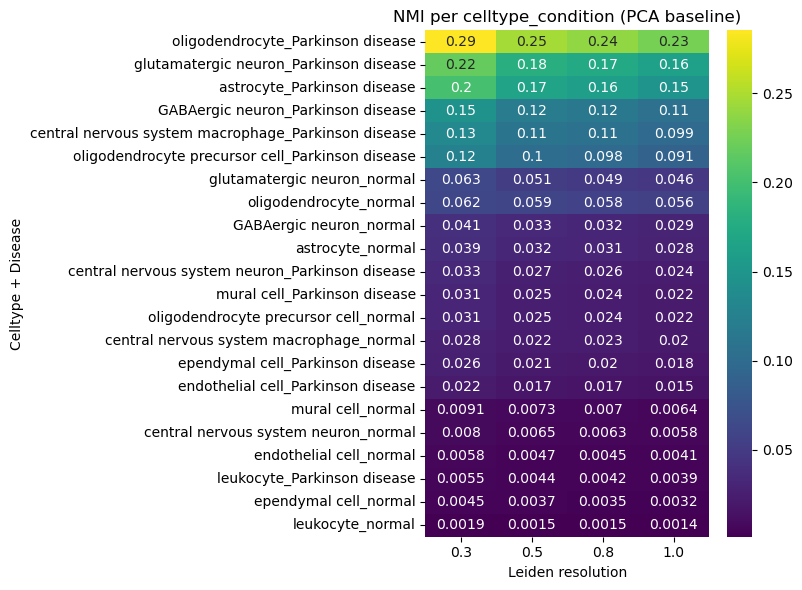

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(sorted_pivot, annot=True, cmap="viridis")
plt.title("NMI per celltype_condition (PCA baseline)")
plt.xlabel("Leiden resolution")
plt.ylabel("Celltype + Disease")
plt.tight_layout()
plt.show()
